In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy
from datetime import datetime
import statsmodels.formula.api as smf

from matplotlib import style
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.font_manager import FontProperties
from pylab import mpl
import platform

# 根据操作系统设置中文字体
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows使用黑体
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
elif system == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS使用Arial Unicode MS
    plt.rcParams['axes.unicode_minus'] = False
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']  # Linux使用文泉驿微米黑
    plt.rcParams['axes.unicode_minus'] = False

# 输出矢量图
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# 设置pandas显示选项
pd.set_option('display.max_columns', None)

print(f"当前操作系统: {system}")
print(f"字体设置: {plt.rcParams['font.sans-serif']}")

当前操作系统: Windows
字体设置: ['SimHei']


In [2]:
cross = pd.read_csv(r"D:\class1\TRD_Mnth202509.csv")
from pandas.tseries.offsets import MonthEnd
# 处理月份格式
cross['month'] = pd.to_datetime(cross['Trdmnt'], format='%Y-%m') + MonthEnd(1)
# 补齐股票代码 如果不满6位 在前面补上0
cross['Stkcd'] = cross['Stkcd'].apply(lambda x: '{:0>6}'.format(x)) # 6位股票代码
# 重命名列以匹配后续代码
cross.rename(columns={'Mretwd': 'Return', 'Msmvosd': 'floatingvalue', 'Msmvttl': 'totalvalue'}, inplace=True)

# 导入无风险利率数据
rf_data = pd.read_csv(r"D:\class1\Marketret_mon_stock2024.csv")
# 处理月份格式
rf_data['month'] = pd.to_datetime(rf_data['month'], format='%b %Y') + MonthEnd(1)
# 只保留需要的列
rf_data = rf_data[['month', 'rfmonth']]

# 合并无风险利率到cross
cross = pd.merge(cross, rf_data, on='month', how='left')

# 添加一个序列 用来统计公司上市的第几个月
cross = cross.sort_values(by=['Stkcd', 'month'])
cross['list_month'] = cross.groupby('Stkcd').cumcount() + 1

# 计算超额收益率
cross['ret'] = cross['Return'] - cross['rfmonth']
cross['floatingvalue'] = cross['floatingvalue'] * 1000
cross['totalvalue'] = cross['totalvalue'] * 1000

cross

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret
0,000001,1991-04,3,49.00,30,43.68,13400,6.150000e+05,1.157520e+09,2.118487e+09,20,NaN,NaN,4,1991-04-03,NaN,NaN,1991-04-30,0.006651,1,NaN
1,000001,1991-05,2,43.46,31,38.34,187800,7.675000e+06,1.016010e+09,1.859497e+09,24,-0.122253,0.235714,4,1991-04-03,NaN,NaN,1991-05-31,0.006092,2,-0.128345
2,000001,1991-06,1,38.53,28,33.99,30600,1.094000e+06,9.007350e+08,1.648521e+09,23,-0.113459,-0.113459,4,1991-04-03,NaN,NaN,1991-06-30,0.006092,3,-0.119551
3,000001,1991-07,1,33.65,31,29.54,6100,1.940430e+05,7.828100e+08,1.432695e+09,16,-0.130921,-0.130921,4,1991-04-03,NaN,NaN,1991-07-31,0.006092,4,-0.137013
4,000001,1991-08,1,29.39,31,15.00,3243100,4.957624e+07,6.748338e+08,1.346275e+09,15,-0.411588,-0.411587,4,1991-08-01,NaN,NaN,1991-08-31,0.006092,5,-0.417680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886908,920992,2025-05,6,20.00,30,20.46,92609592,1.922463e+09,5.707967e+08,1.979115e+09,19,0.051312,0.051715,64,2023-04-25,0.0,0.0,2025-05-31,NaN,32,NaN
886909,920992,2025-06,3,20.40,30,21.26,73152031,1.580767e+09,5.931152e+08,2.056500e+09,20,0.039101,0.039101,64,2023-04-25,0.0,0.0,2025-06-30,NaN,33,NaN
886910,920992,2025-07,1,21.13,31,22.44,96064221,2.126994e+09,6.260351e+08,2.170642e+09,23,0.055503,0.055503,64,2023-04-25,0.0,0.0,2025-07-31,NaN,34,NaN
886911,920992,2025-08,1,22.12,29,21.65,63953451,1.432608e+09,6.039955e+08,2.094225e+09,21,-0.035205,-0.035205,64,2023-04-25,0.0,0.0,2025-08-31,NaN,35,NaN


In [3]:
# 生成下一个月的收益率

# 方法1：补全所有个股的日期序列，再使用shift
# 创建所有日期和股票代码的完整组合
all_months = pd.DataFrame(cross['month'].unique(), columns=['month'])
all_stocks = pd.DataFrame(cross['Stkcd'].unique(), columns=['Stkcd'])
# 创建笛卡尔积 - 所有股票和所有月份的组合
full_index = all_stocks.merge(all_months, how='cross')

# 将原始数据合并到完整索引中
cross_full = full_index.merge(cross, on=['Stkcd', 'month'], how='left')
# 按股票代码和月份排序
cross_full = cross_full.sort_values(['Stkcd', 'month'])
# 使用shift生成下月收益率
cross_full['next_ret'] = cross_full.groupby('Stkcd')['ret'].shift(-1)

# 只保留原始数据存在的行
cross = cross.merge(cross_full[['Stkcd', 'month', 'next_ret']], 
                    on=['Stkcd', 'month'], how='right')

# 添加一个变量 用来统计过去一年的交易日数量之和
cross['Cumsum_tradingday'] = cross.groupby('Stkcd')['Ndaytrd'].transform(lambda x: x.rolling(window=12, min_periods=1).sum())
print("方法1完成：补全日期序列后使用shift")

cross = cross[(cross['month'] >= '1995-01-31') & (cross['month'] <= '2024-12-31')]
cross

方法1完成：补全日期序列后使用shift


,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday
49,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0
50,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0
51,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0
52,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0
53,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2453228,920992,2024-08,1.0,8.50,30.0,8.19,14436632.0,1.185912e+08,2.284861e+08,7.922264e+08,22.0,-0.037603,-0.037603,64.0,2023-04-25,0.0,0.0,2024-08-31,0.001118,23.0,-0.038721,0.276049,242.0
2453229,920992,2024-09,2.0,8.15,30.0,10.46,18109819.0,1.566140e+08,2.918149e+08,1.011806e+09,19.0,0.277167,0.277167,64.0,2023-04-25,0.0,0.0,2024-09-30,0.001118,24.0,0.276049,0.389895,241.0
2453230,920992,2024-10,8.0,13.02,31.0,14.55,86774237.0,1.145494e+09,4.059185e+08,1.407435e+09,18.0,0.391013,0.391013,64.0,2023-04-25,0.0,0.0,2024-10-31,0.001118,25.0,0.389895,0.241494,242.0
2453231,920992,2024-11,1.0,14.69,29.0,18.08,130783392.0,2.346534e+09,5.043990e+08,1.748895e+09,21.0,0.242612,0.242612,64.0,2023-04-25,0.0,0.0,2024-11-30,0.001118,26.0,0.241494,-0.243928,241.0


In [4]:
from pandas.tseries.offsets import MonthEnd # 月末
Market_ret = pd.read_csv(r"D:\class1\Marketret_mon_stock2024.csv")
Market_ret['month'] = pd.to_datetime(Market_ret['month']) + MonthEnd(0)
Market_ret.set_index('month', inplace=True)
Market_ret.sort_index(inplace=True)
Market_ret = Market_ret.drop(columns=['Unnamed: 0'])
Market_ret.rename(columns={'ret': 'MKT'}, inplace=True)
Market_ret

C:\Users\sa'si'gei\AppData\Local\Temp\ipykernel_19132\901974064.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Market_ret['month'] = pd.to_datetime(Market_ret['month']) + MonthEnd(0)


,MarketR,MarketR_e,rfmonth,MKT,ret_e,marketret3,marketret6,marketret12,Q
month,,,,,,,,,
1991-01-31,0.029998,0.036554,0.006930,0.023068,0.029624,-0.084127,-0.305662,0.254049,1991 Q1
1991-02-28,0.010203,0.021860,0.006930,0.003273,0.014930,-0.183573,-0.384745,0.241492,1991 Q1
1991-03-31,-0.099663,-0.060425,0.006930,-0.106593,-0.067355,-0.252928,-0.445049,0.288857,1991 Q1
1991-04-30,-0.079652,-0.031449,0.006651,-0.086303,-0.038100,-0.234776,-0.394937,0.691749,1991 Q2
1991-05-31,-0.074521,0.005375,0.006092,-0.080613,-0.000717,-0.236294,0.181673,1.542701,1991 Q2
...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.031468,-0.033685,0.001118,-0.032586,-0.034803,0.151050,NaN,NaN,2024 Q3
2024-09-30,0.195992,0.227078,0.001118,0.194874,0.225960,0.200147,NaN,NaN,2024 Q3
2024-10-31,-0.003409,0.070220,0.001118,-0.004527,0.069102,0.000228,NaN,NaN,2024 Q4


In [5]:
cross = pd.merge(cross,Market_ret[['MKT']],left_on='month',right_on='month',how='left')
cross

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2112835,920992,2024-08,1.0,8.50,30.0,8.19,14436632.0,1.185912e+08,2.284861e+08,7.922264e+08,22.0,-0.037603,-0.037603,64.0,2023-04-25,0.0,0.0,2024-08-31,0.001118,23.0,-0.038721,0.276049,242.0,-0.032586
2112836,920992,2024-09,2.0,8.15,30.0,10.46,18109819.0,1.566140e+08,2.918149e+08,1.011806e+09,19.0,0.277167,0.277167,64.0,2023-04-25,0.0,0.0,2024-09-30,0.001118,24.0,0.276049,0.389895,241.0,0.194874
2112837,920992,2024-10,8.0,13.02,31.0,14.55,86774237.0,1.145494e+09,4.059185e+08,1.407435e+09,18.0,0.391013,0.391013,64.0,2023-04-25,0.0,0.0,2024-10-31,0.001118,25.0,0.389895,0.241494,242.0,-0.004527
2112838,920992,2024-11,1.0,14.69,29.0,18.08,130783392.0,2.346534e+09,5.043990e+08,1.748895e+09,21.0,0.242612,0.242612,64.0,2023-04-25,0.0,0.0,2024-11-30,0.001118,26.0,0.241494,-0.243928,241.0,0.008606


In [6]:
# 重新读取EP数据并转换month列
EP = pd.read_csv(r"D:\class1\EP_individual_mon2024.csv")
EP['Stkcd'] = EP['Stkcd'].apply(lambda x: '{:0>6}'.format(x))

# 转换month列为日期格式
# 根据数据规律: 1991.250000 -> 1991年3月, 1991.333333 -> 1991年4月
# 小数部分 = (month - 1) / 12, 所以 month = round(小数部分 * 12) + 1
EP['year'] = EP['month'].astype(int)
EP['month_decimal'] = EP['month'] - EP['year']
EP['month_num'] = (EP['month_decimal'] * 12).round().astype(int) + 1
# 处理边界情况
EP.loc[EP['month_num'] > 12, 'year'] += 1
EP.loc[EP['month_num'] > 12, 'month_num'] -= 12
EP['month'] = pd.to_datetime(EP['year'].astype(str) + '-' + EP['month_num'].astype(str) + '-01')
EP = EP.drop(['year', 'month_decimal', 'month_num'], axis=1)
EP['month'] = EP['month'] + MonthEnd(1)
EP = EP[['Stkcd', 'month', 'ep', 'ep_recent']]
EP

,Stkcd,month,ep,ep_recent
0,000001,1991-04-30,NaN,NaN
1,000001,1991-05-31,NaN,NaN
2,000001,1991-06-30,NaN,NaN
3,000001,1991-07-31,NaN,NaN
4,000001,1991-08-31,NaN,NaN
...,...,...,...,...
809599,605599,2024-08-31,0.079184,0.046498
809600,605599,2024-09-30,0.071525,0.042001
809601,605599,2024-10-31,0.077932,0.063816
809602,605599,2024-11-30,0.072171,0.059100


In [7]:
cross = pd.merge(cross,EP[['Stkcd','month','ep','ep_recent']],on=['Stkcd','month'],how='left')
cross

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2112835,920992,2024-08,1.0,8.50,30.0,8.19,14436632.0,1.185912e+08,2.284861e+08,7.922264e+08,22.0,-0.037603,-0.037603,64.0,2023-04-25,0.0,0.0,2024-08-31,0.001118,23.0,-0.038721,0.276049,242.0,-0.032586,NaN,NaN
2112836,920992,2024-09,2.0,8.15,30.0,10.46,18109819.0,1.566140e+08,2.918149e+08,1.011806e+09,19.0,0.277167,0.277167,64.0,2023-04-25,0.0,0.0,2024-09-30,0.001118,24.0,0.276049,0.389895,241.0,0.194874,NaN,NaN
2112837,920992,2024-10,8.0,13.02,31.0,14.55,86774237.0,1.145494e+09,4.059185e+08,1.407435e+09,18.0,0.391013,0.391013,64.0,2023-04-25,0.0,0.0,2024-10-31,0.001118,25.0,0.389895,0.241494,242.0,-0.004527,NaN,NaN
2112838,920992,2024-11,1.0,14.69,29.0,18.08,130783392.0,2.346534e+09,5.043990e+08,1.748895e+09,21.0,0.242612,0.242612,64.0,2023-04-25,0.0,0.0,2024-11-30,0.001118,26.0,0.241494,-0.243928,241.0,0.008606,NaN,NaN


In [8]:
fenweishu = pd.DataFrame(
    cross.groupby(['month'])['totalvalue'].quantile(0.3))
fenweishu.columns = ['fenweishu_guimo']
fenweishu

,fenweishu_guimo
month,
1995-01-31,3.958033e+08
1995-02-28,3.907805e+08
1995-03-31,4.341120e+08
1995-04-30,3.835094e+08
1995-05-31,4.590161e+08
...,...
2024-08-31,2.442662e+09
2024-09-30,3.012217e+09
2024-10-31,3.234660e+09


In [9]:
cross_new = pd.merge(cross,fenweishu,on='month',how='left')
cross_new = cross_new[cross_new['totalvalue'] > cross_new['fenweishu_guimo']]
cross_new

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent,fenweishu_guimo
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427,3.958033e+08
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763,3.907805e+08
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823,4.341120e+08
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306,3.835094e+08
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349,4.590161e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2112451,920985,2022-08,8.0,11.05,31.0,11.43,245414411.0,3.490897e+09,1.352501e+09,3.445035e+09,18.0,NaN,NaN,64.0,2022-08-08,0.0,0.0,2022-08-31,0.001241,1.0,NaN,-0.124667,18.0,-0.020875,NaN,NaN,3.370444e+09
2112452,920985,2022-09,1.0,11.60,30.0,10.02,69513984.0,7.992666e+08,1.185657e+09,3.100952e+09,21.0,-0.123360,-0.123360,64.0,2022-09-06,0.0,0.0,2022-09-30,0.001307,2.0,-0.124667,0.025581,39.0,-0.065953,NaN,NaN,3.024944e+09
2112453,920985,2022-10,10.0,10.06,31.0,10.29,33100688.0,3.486847e+08,1.217606e+09,3.184510e+09,16.0,0.026946,0.026946,64.0,2022-09-06,0.0,0.0,2022-10-31,0.001365,3.0,0.025581,-0.014970,55.0,-0.042599,NaN,NaN,3.165959e+09
2112477,920985,2024-10,8.0,8.60,31.0,15.31,486954437.0,5.439326e+09,2.058722e+09,4.738081e+09,18.0,1.261448,1.261448,64.0,2023-02-22,0.0,0.0,2024-10-31,0.001118,27.0,1.260330,-0.157878,242.0,-0.004527,NaN,NaN,3.234660e+09


In [10]:
cross_new = cross_new[cross_new['Ndaytrd'] >= 7]

cross_new = cross_new[cross_new['list_month'] > 6]
cross_new = cross_new[cross_new['Cumsum_tradingday'] >= 120]
cross_new = cross_new[(cross_new['Markettype'] == 1) | (cross_new['Markettype'] == 4) | (cross_new['Markettype'] == 16)] # 上海A 深圳A 创业板
# ep是完整的
cross_new = cross_new.dropna(subset=['ep'])
cross_new

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent,fenweishu_guimo
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427,3.958033e+08
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763,3.907805e+08
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823,4.341120e+08
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306,3.835094e+08
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349,4.590161e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779475,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586,0.079184,0.046498,2.442662e+09
1779476,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874,0.071525,0.042001,3.012217e+09
1779477,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527,0.077932,0.063816,3.234660e+09
1779478,605599,2024-11,1.0,10.63,29.0,11.50,108258572.0,1.199394e+09,8.944445e+09,8.944445e+09,21.0,0.079812,0.079812,1.0,2024-09-09,0.0,0.0,2024-11-30,0.001118,39.0,0.078694,-0.014161,241.0,0.008606,0.072171,0.059100,3.392681e+09


In [11]:
guimo = cross_new.groupby(['month'])['totalvalue'].quantile(0.5).to_frame()
guimo.columns = ['guimo']
guimo

,guimo
month,
1995-01-31,8.413909e+08
1995-02-28,8.085674e+08
1995-03-31,9.415474e+08
1995-04-30,8.264294e+08
1995-05-31,9.532519e+08
...,...
2024-08-31,5.863931e+09
2024-09-30,7.220504e+09
2024-10-31,7.787871e+09


In [12]:
jiazhi = cross_new.groupby(['month'])['ep'].quantile([0.3,0.7]).to_frame()
jiazhi.reset_index(inplace=True)
jiazhi = jiazhi.pivot_table(index='month',columns='level_1',values='ep')
jiazhi.columns = ['jiazhi_30','jiazhi_70']
jiazhi

,jiazhi_30,jiazhi_70
month,,
1995-01-31,0.028942,0.079487
1995-02-28,0.033836,0.075549
1995-03-31,0.028213,0.062519
1995-04-30,0.037206,0.086090
1995-05-31,0.030822,0.072632
...,...,...
2024-08-31,0.008065,0.051295
2024-09-30,0.005714,0.042319
2024-10-31,0.003570,0.040921


In [13]:
cross_new = pd.merge(cross_new,guimo,on='month',how='left')
cross_new = pd.merge(cross_new,jiazhi,on='month',how='left')
cross_new

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent,fenweishu_guimo,guimo,jiazhi_30,jiazhi_70
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427,3.958033e+08,8.413909e+08,0.028942,0.079487
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763,3.907805e+08,8.085674e+08,0.033836,0.075549
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823,4.341120e+08,9.415474e+08,0.028213,0.062519
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306,3.835094e+08,8.264294e+08,0.037206,0.086090
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349,4.590161e+08,9.532519e+08,0.030822,0.072632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504099,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586,0.079184,0.046498,2.442662e+09,5.863931e+09,0.008065,0.051295
504100,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874,0.071525,0.042001,3.012217e+09,7.220504e+09,0.005714,0.042319
504101,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527,0.077932,0.063816,3.234660e+09,7.787871e+09,0.003570,0.040921
504102,605599,2024-11,1.0,10.63,29.0,11.50,108258572.0,1.199394e+09,8.944445e+09,8.944445e+09,21.0,0.079812,0.079812,1.0,2024-09-09,0.0,0.0,2024-11-30,0.001118,39.0,0.078694,-0.014161,241.0,0.008606,0.072171,0.059100,3.392681e+09,8.019636e+09,0.003562,0.039451


In [14]:
# note the totalvale > guimo will be big, else small
# note the ep > jiazhi_70 will be value, else > jiazhi_30 will be median, else growth
cross_new['size'] = np.where(cross_new['totalvalue'] > cross_new['guimo'],'B','S')
cross_new['value'] = np.where(cross_new['ep'] > cross_new['jiazhi_70'],'V',
                              np.where(cross_new['ep'] > cross_new['jiazhi_30'],'M','G'))
cross_new = cross_new.dropna(subset=['next_ret','totalvalue'])
cross_new

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent,fenweishu_guimo,guimo,jiazhi_30,jiazhi_70,size,value
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427,3.958033e+08,8.413909e+08,0.028942,0.079487,B,M
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763,3.907805e+08,8.085674e+08,0.033836,0.075549,B,V
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823,4.341120e+08,9.415474e+08,0.028213,0.062519,B,V
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306,3.835094e+08,8.264294e+08,0.037206,0.086090,B,M
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349,4.590161e+08,9.532519e+08,0.030822,0.072632,B,V
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504098,605599,2024-07,1.0,12.78,31.0,11.49,54949980.0,6.610917e+08,6.740928e+09,8.936667e+09,23.0,-0.097408,-0.097408,1.0,2022-09-09,0.0,0.0,2024-07-31,0.001184,35.0,-0.098592,-0.066392,243.0,-0.000624,0.078272,0.028314,2.521012e+09,6.148011e+09,0.008836,0.050913,B,V
504099,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586,0.079184,0.046498,2.442662e+09,5.863931e+09,0.008065,0.051295,B,V
504100,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874,0.071525,0.042001,3.012217e+09,7.220504e+09,0.005714,0.042319,B,V
504101,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527,0.077932,0.063816,3.234660e+09,7.787871e+09,0.003570,0.040921,B,V


In [15]:
SV = cross_new[(cross_new['size'] == 'S') & (cross_new['value'] == 'V')].groupby(['month']).apply(lambda x: np.average(x['next_ret'],weights=x['totalvalue']),include_groups=False).to_frame()
SV.columns = ['SV']
SM = cross_new[(cross_new['size'] == 'S') & (cross_new['value'] == 'M')].groupby(['month']).apply(lambda x: np.average(x['next_ret'],weights=x['totalvalue']),include_groups=False).to_frame()
SM.columns = ['SM']
SG = cross_new[(cross_new['size'] == 'S') & (cross_new['value'] == 'G')].groupby(['month']).apply(lambda x: np.average(x['next_ret'],weights=x['totalvalue']),include_groups=False).to_frame()
SG.columns = ['SG']
BV = cross_new[(cross_new['size'] == 'B') & (cross_new['value'] == 'V')].groupby(['month']).apply(lambda x: np.average(x['next_ret'],weights=x['totalvalue']),include_groups=False).to_frame()
BV.columns = ['BV']
BM = cross_new[(cross_new['size'] == 'B') & (cross_new['value'] == 'M')].groupby(['month']).apply(lambda x: np.average(x['next_ret'],weights=x['totalvalue']),include_groups=False).to_frame()
BM.columns = ['BM']
BG = cross_new[(cross_new['size'] == 'B') & (cross_new['value'] == 'G')].groupby(['month']).apply(lambda x: np.average(x['next_ret'],weights=x['totalvalue']),include_groups=False).to_frame()
BG.columns = ['BG']

In [16]:
# 改进后的代码
def weighted_ret(group):
    return np.average(group['next_ret'], weights=group['totalvalue'])

def calc_portfolio_returns(data):
    portfolios = {}
    for size in ['S', 'B']:
        for value in ['V', 'M', 'G']:
            mask = (data['size'] == size) & (data['value'] == value)
            port_name = f'{size}{value}'
            portfolios[port_name] = (data[mask]
                                   .groupby('month')
                                   .apply(weighted_ret,include_groups=False)
                                   .to_frame(name=port_name))
    return pd.concat(portfolios.values(), axis=1)
    
six_portfolio = calc_portfolio_returns(cross_new)
# index is month and plus one month
six_portfolio.index = six_portfolio.index + MonthEnd(1)
six_portfolio = six_portfolio['2000-01':]
six_portfolio

,SV,SM,SG,BV,BM,BG
month,,,,,,
2000-01-31,0.111051,0.135348,0.167612,0.104549,0.184193,0.168754
2000-02-29,0.124971,0.139342,0.146752,0.062845,0.109953,0.159660
2000-03-31,0.112025,0.088826,0.129694,0.034401,0.016213,0.015274
2000-04-30,0.020844,0.019261,0.015617,0.032513,0.014682,0.008828
2000-05-31,0.032633,0.033800,0.050758,0.038244,0.021954,-0.014245
...,...,...,...,...,...,...
2024-08-31,-0.041159,-0.039789,-0.034078,-0.021872,-0.041715,-0.066688
2024-09-30,0.198623,0.224225,0.265612,0.166173,0.222903,0.243758
2024-10-31,0.012293,0.062552,0.143215,-0.045347,-0.007577,0.090710


In [17]:
def calc_factors(portfolios):
    # SMB因子
    smb = ((portfolios['SV'] + portfolios['SM'] + portfolios['SG'])/3 - 
           (portfolios['BV'] + portfolios['BM'] + portfolios['BG'])/3)
    
    # HML因子
    hml = ((portfolios['SV'] + portfolios['BV'])/2 - 
           (portfolios['SG'] + portfolios['BG'])/2)
    
    return pd.DataFrame({
        'SMB': smb,
        'HML': hml
    })

factors = calc_factors(six_portfolio)
factors

,SMB,HML
month,,
2000-01-31,-0.014495,-0.060382
2000-02-29,0.026202,-0.059298
2000-03-31,0.088219,0.000729
2000-04-30,-0.000101,0.014456
2000-05-31,0.023746,0.017182
...,...,...
2024-08-31,0.005083,0.018868
2024-09-30,0.018542,-0.072287
2024-10-31,0.060091,-0.133489


In [22]:
factors = pd.merge(factors, Market_ret[['MKT']], left_index=True, right_index=True, how='left')
factors = factors[['MKT','SMB','HML']]
factors
factors.to_csv(r"D:\class1\datatas\factors_3f.csv")

,MKT,SMB,HML
month,,,
2000-01-31,0.158982,-0.014495,-0.060382
2000-02-29,0.120168,0.026202,-0.059298
2000-03-31,0.054070,0.088219,0.000729
2000-04-30,0.011158,-0.000101,0.014456
2000-05-31,0.025835,0.023746,0.017182
...,...,...,...
2024-08-31,-0.032586,0.005083,0.018868
2024-09-30,0.194874,0.018542,-0.072287
2024-10-31,-0.004527,0.060091,-0.133489


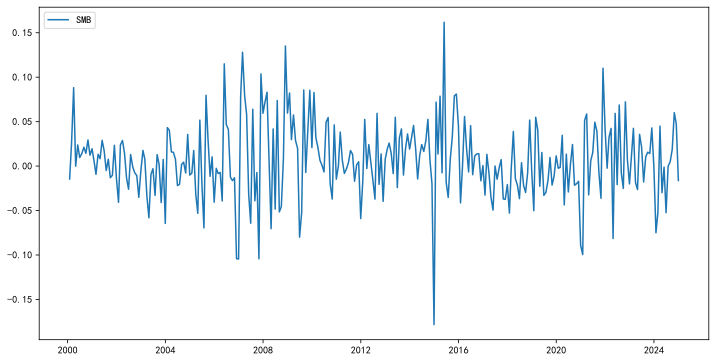

In [23]:
# plot SMB
fig = plt.figure(figsize=(12,6))
plt.plot(factors['SMB'], label='SMB')
plt.legend(loc='upper left')
plt.show();

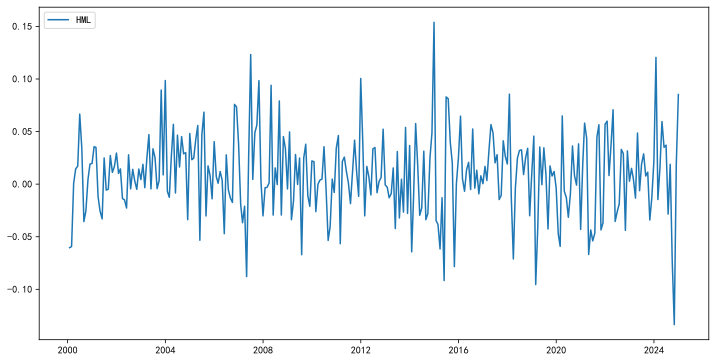

In [24]:
# plot HML
fig = plt.figure(figsize=(12,6))
plt.plot(factors['HML'], label='HML')
plt.legend(loc='upper left')
plt.show();

In [25]:
# summary of the factor
factors[:'2016-12'].describe()
factors[:'2016-12'].corr()

,MKT,SMB,HML
count,204.000000,204.000000,204.000000
mean,0.008559,0.009720,0.009844
std,0.085672,0.043825,0.037299
min,-0.268349,-0.178301,-0.091632
25%,-0.049015,-0.013106,-0.011949
50%,0.011751,0.007880,0.007282
75%,0.050495,0.030435,0.030187
max,0.296042,0.161752,0.153862


,MKT,SMB,HML
MKT,1.000000,0.220290,-0.324627
SMB,0.220290,1.000000,-0.601597
HML,-0.324627,-0.601597,1.000000


In [26]:
# regression
model = smf.ols('SMB ~ 1',
                 data=factors['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 2})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    SMB   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                 周五, 12 12月 2025   Prob (F-statistic):                nan
Time:                        15:07:01   Log-Likelihood:                 525.07
No. Observations:                 300   AIC:                            -1048.
Df Residuals:                     299   BIC:                            -1044.
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0062      0.003      2.455      0.0

In [27]:
# regression
model = smf.ols('HML ~ 1',
                 data=factors['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 2})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    HML   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                 周五, 12 12月 2025   Prob (F-statistic):                nan
Time:                        15:07:13   Log-Likelihood:                 551.07
No. Observations:                 300   AIC:                            -1100.
Df Residuals:                     299   BIC:                            -1096.
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0090      0.002      4.057      0.0

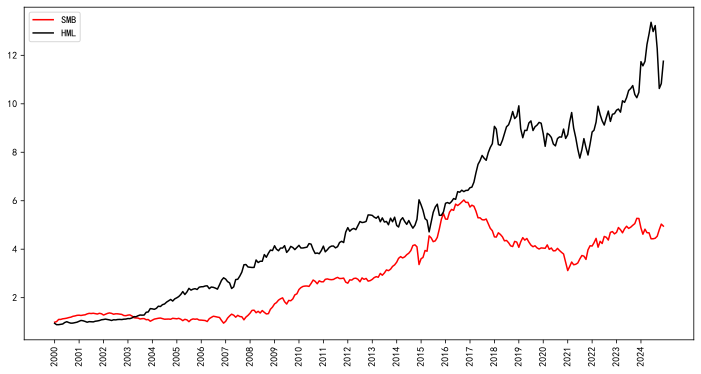

In [29]:
fig = plt.figure(figsize=(12,6))

factors['SMBprice'] = (factors['SMB'] + 1).cumprod()
factors['HMLprice'] = (factors['HML'] + 1).cumprod()

plt.plot(factors['SMBprice'],color='red',label='SMB')
plt.plot(factors['HMLprice'],color='black',label='HML')
plt.legend(loc='upper left')

xticks = factors.index[::12]
xtick_labels = [label.year for label in xticks]
plt.xticks(xticks, xtick_labels, rotation=90)

plt.show();

In [30]:
# 计算累积收益率
factors['cumulative_return'] = (1 + factors['SMB']).cumprod()

# 计算滚动最大值
factors['rolling_max'] = factors['cumulative_return'].cummax()

# 计算回撤
factors['drawdown'] = factors['cumulative_return'] / factors['rolling_max'] - 1

# 计算最大回撤
max_drawdown = factors['drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown}")

Maximum Drawdown: -0.4830493755538746


In [31]:
# 找出最大回撤的时间
max_drawdown_end = factors['drawdown'].idxmin() # 返回 Series 中最小值的索引
max_drawdown_start = factors.loc[:max_drawdown_end, 'cumulative_return'].idxmax() # 这部分代码选择了从数据开始到 max_drawdown_end 时间点之间的所有累积收益率

print(f"Maximum Drawdown: {max_drawdown}")
print(f"Maximum Drawdown Start Date: {max_drawdown_start}")
print(f"Maximum Drawdown End Date: {max_drawdown_end}")

Maximum Drawdown: -0.4830493755538746
Maximum Drawdown Start Date: 2016-10-31 00:00:00
Maximum Drawdown End Date: 2021-01-31 00:00:00


In [32]:
# 计算累积收益率
factors['cumulative_return'] = (1 + factors['HML']).cumprod()

# 计算滚动最大值
factors['rolling_max'] = factors['cumulative_return'].cummax()

# 计算回撤
factors['drawdown'] = factors['cumulative_return'] / factors['rolling_max'] - 1

# 计算最大回撤
max_drawdown = factors['drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown}")

Maximum Drawdown: -0.21892803583229292


In [33]:
# 找出最大回撤的时间
max_drawdown_end = factors['drawdown'].idxmin() # 返回 Series 中最小值的索引
max_drawdown_start = factors.loc[:max_drawdown_end, 'cumulative_return'].idxmax() # 这部分代码选择了从数据开始到 max_drawdown_end 时间点之间的所有累积收益率

print(f"Maximum Drawdown: {max_drawdown}")
print(f"Maximum Drawdown Start Date: {max_drawdown_start}")
print(f"Maximum Drawdown End Date: {max_drawdown_end}")

Maximum Drawdown: -0.21892803583229292
Maximum Drawdown Start Date: 2014-12-31 00:00:00
Maximum Drawdown End Date: 2015-05-31 00:00:00


In [34]:
# 构造totalvalue十分组投资策略
def calc_decile_portfolios(data):
    """
    根据totalvalue构造十分组投资组合
    """
    portfolios = {}
    
    # 为每个月的每只股票分配十分组标签
    def assign_decile(group):
        # 计算十分位数
        quantiles = [group['totalvalue'].quantile(i/10) for i in range(11)]
        # 分配到相应的十分组
        labels = pd.cut(group['totalvalue'], bins=quantiles, labels=False, include_lowest=True, duplicates='drop')
        return labels
    
    data_copy = data.copy()
    data_copy['decile'] = data_copy.groupby('month', group_keys=False).apply(
        lambda x: assign_decile(x), include_groups=False
    )
    
    # 计算每个十分组的加权收益率
    for i in range(10):
        decile_name = f'P{i+1}'
        portfolios[decile_name] = (
            data_copy[data_copy['decile'] == i]
            .groupby('month')
            .apply(lambda x: np.average(x['next_ret'], weights=x['totalvalue']), include_groups=False)
            .to_frame(name=decile_name)
        )
    
    return pd.concat(portfolios.values(), axis=1)

# 计算十分组投资组合
decile_portfolios = calc_decile_portfolios(cross_new)
# 调整索引：投资组合收益率应该对应下一个月
decile_portfolios.index = decile_portfolios.index + MonthEnd(1)
decile_portfolios = decile_portfolios['2000-01':]

print("十分组投资组合描述统计:")
decile_portfolios.describe()

十分组投资组合描述统计:


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.012957,0.010906,0.009259,0.008795,0.008189,0.006759,0.008490,0.005950,0.007004,0.006131
std,0.098215,0.095568,0.094037,0.093729,0.091502,0.089529,0.088376,0.085206,0.082319,0.071781
min,-0.313473,-0.314426,-0.310207,-0.313607,-0.312032,-0.297306,-0.301547,-0.310436,-0.277671,-0.259479
25%,-0.041697,-0.042142,-0.043890,-0.043888,-0.044527,-0.046099,-0.042734,-0.042061,-0.041358,-0.039249
50%,0.011018,0.008898,0.005361,0.008197,0.004723,0.006446,0.007021,0.006185,0.003591,0.003518
75%,0.062178,0.060742,0.056843,0.051605,0.055211,0.051847,0.052685,0.047264,0.050414,0.041756
max,0.389229,0.351794,0.333635,0.359748,0.349341,0.330660,0.336014,0.366914,0.321600,0.284506


In [35]:
decile_portfolios['size_portfolio'] = decile_portfolios['P1'] - decile_portfolios['P10']
decile_portfolios = pd.merge(decile_portfolios, factors, left_index=True, right_index=True, how='left')
model_size = smf.ols('size_portfolio ~ 1',
                 data=decile_portfolios['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_size.summary())
model_size_3factors = smf.ols('size_portfolio ~ MKT + SMB + HML',
                 data=decile_portfolios['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_size_3factors.summary())

                            OLS Regression Results                            
Dep. Variable:         size_portfolio   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                 周五, 12 12月 2025   Prob (F-statistic):                nan
Time:                        15:09:48   Log-Likelihood:                 352.05
No. Observations:                 300   AIC:                            -702.1
Df Residuals:                     299   BIC:                            -698.4
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0068      0.004      1.677      0.0

In [36]:
# 构造ep十分组投资策略
def calc_value_decile_portfolios(data):
    """
    根据ep构造十分组投资组合
    """
    portfolios = {}
    
    # 为每个月的每只股票分配十分组标签
    def assign_decile(group):
        # 计算十分位数
        quantiles = [group['ep'].quantile(i/10) for i in range(11)]
        # 分配到相应的十分组
        labels = pd.cut(group['ep'], bins=quantiles, labels=False, include_lowest=True, duplicates='drop')
        return labels
    
    data_copy = data.copy()
    data_copy['ep_decile'] = data_copy.groupby('month', group_keys=False).apply(
        lambda x: assign_decile(x), include_groups=False
    )
    
    # 计算每个十分组的加权收益率
    for i in range(10):
        decile_name = f'V{i+1}'
        portfolios[decile_name] = (
            data_copy[data_copy['ep_decile'] == i]
            .groupby('month')
            .apply(lambda x: np.average(x['next_ret'], weights=x['totalvalue']), include_groups=False)
            .to_frame(name=decile_name)
        )
    
    return pd.concat(portfolios.values(), axis=1)

# 计算十分组投资组合
value_decile_portfolios = calc_value_decile_portfolios(cross_new)
# 调整索引：投资组合收益率应该对应下一个月
value_decile_portfolios.index = value_decile_portfolios.index + MonthEnd(1)
value_decile_portfolios = value_decile_portfolios['2000-01':]

print("价值因子十分组投资组合描述统计:")
value_decile_portfolios.describe()

价值因子十分组投资组合描述统计:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.001888,0.001358,0.000209,0.004280,0.005552,0.006544,0.007655,0.008517,0.006315,0.010598
std,0.092882,0.096604,0.091181,0.087070,0.085613,0.079333,0.080416,0.075773,0.076977,0.077144
min,-0.277141,-0.339272,-0.340835,-0.319126,-0.325382,-0.296989,-0.286992,-0.265087,-0.244541,-0.343513
25%,-0.051491,-0.053434,-0.051239,-0.045417,-0.045415,-0.036640,-0.039013,-0.034925,-0.043043,-0.033924
50%,0.001570,0.000511,-0.002153,0.002862,0.001537,0.003867,0.006047,0.004664,0.005843,0.009773
75%,0.054469,0.049023,0.048068,0.046851,0.044613,0.048215,0.045993,0.049329,0.044344,0.048372
max,0.347968,0.408390,0.399984,0.298916,0.275227,0.251219,0.336570,0.215228,0.350877,0.287287


In [37]:
value_decile_portfolios['value_portfolio'] = value_decile_portfolios['V10'] - value_decile_portfolios['V1']
value_decile_portfolios = pd.merge(value_decile_portfolios, factors, left_index=True, right_index=True, how='left')
model_value = smf.ols('value_portfolio ~ 1',
                 data=value_decile_portfolios['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_value.summary())
model_value_3factors = smf.ols('value_portfolio ~ MKT + SMB + HML',
                 data=value_decile_portfolios['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_value_3factors.summary())

                            OLS Regression Results                            
Dep. Variable:        value_portfolio   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                 周五, 12 12月 2025   Prob (F-statistic):                nan
Time:                        15:10:26   Log-Likelihood:                 398.68
No. Observations:                 300   AIC:                            -795.4
Df Residuals:                     299   BIC:                            -791.7
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0087      0.003      2.935      0.0

In [38]:
# 构造过去一个月ret十分组投资策略（Reversal效应）
def calc_reversal_decile_portfolios(data):
    """
    根据过去一个月的ret构造十分组投资组合
    """
    portfolios = {}
    
    # 为每个月的每只股票分配十分组标签
    def assign_decile(group):
        # 计算十分位数
        quantiles = [group['ret'].quantile(i/10) for i in range(11)]
        # 分配到相应的十分组
        labels = pd.cut(group['ret'], bins=quantiles, labels=False, include_lowest=True, duplicates='drop')
        return labels
    
    data_copy = data.copy()
    data_copy['ret_decile'] = data_copy.groupby('month', group_keys=False).apply(
        lambda x: assign_decile(x), include_groups=False
    )
    
    # 计算每个十分组的加权收益率
    for i in range(10):
        decile_name = f'R{i+1}'
        portfolios[decile_name] = (
            data_copy[data_copy['ret_decile'] == i]
            .groupby('month')
            .apply(lambda x: np.average(x['next_ret'], weights=x['totalvalue']), include_groups=False)
            .to_frame(name=decile_name)
        )
    
    return pd.concat(portfolios.values(), axis=1)

# 计算十分组投资组合
reversal_decile_portfolios = calc_reversal_decile_portfolios(cross_new)
# 调整索引：投资组合收益率应该对应下一个月
reversal_decile_portfolios.index = reversal_decile_portfolios.index + MonthEnd(1)
reversal_decile_portfolios = reversal_decile_portfolios['2000-01':]

print("Reversal因子十分组投资组合描述统计:")
reversal_decile_portfolios.describe()

Reversal因子十分组投资组合描述统计:


,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.008428,0.007757,0.010912,0.006903,0.008979,0.008940,0.009805,0.007295,0.004955,0.000459
std,0.089548,0.084056,0.078336,0.077739,0.078371,0.081109,0.077573,0.076820,0.082632,0.090909
min,-0.291675,-0.292793,-0.203748,-0.288798,-0.249733,-0.312390,-0.278851,-0.255624,-0.313648,-0.336323
25%,-0.046267,-0.042515,-0.038916,-0.038760,-0.043317,-0.041299,-0.031973,-0.036176,-0.046613,-0.050358
50%,0.005026,0.007281,0.005143,0.007179,0.005351,0.008128,0.007509,0.005199,0.002589,-0.000317
75%,0.053956,0.049755,0.050323,0.044705,0.047955,0.048369,0.049901,0.045421,0.040448,0.047996
max,0.308758,0.292780,0.258365,0.242705,0.335804,0.326018,0.352338,0.249421,0.349067,0.373963


In [39]:
reversal_decile_portfolios['reversal_portfolio'] = reversal_decile_portfolios['R1'] - reversal_decile_portfolios['R10']
reversal_decile_portfolios = pd.merge(reversal_decile_portfolios, factors, left_index=True, right_index=True, how='left')
model_reversal = smf.ols('reversal_portfolio ~ 1',
                 data=reversal_decile_portfolios['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_reversal.summary())
model_reversal_3factors = smf.ols('reversal_portfolio ~ MKT + SMB + HML',
                 data=reversal_decile_portfolios['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_reversal_3factors.summary())

                            OLS Regression Results                            
Dep. Variable:     reversal_portfolio   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                 周五, 12 12月 2025   Prob (F-statistic):                nan
Time:                        15:11:22   Log-Likelihood:                 382.41
No. Observations:                 300   AIC:                            -762.8
Df Residuals:                     299   BIC:                            -759.1
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0080      0.004      2.268      0.0